# Analisis Kualitas Udara (Polutan) di Kawasan Gresik

## 1. Business Understanding

### 1.1 Latar Belakang

Kabupaten Gresik merupakan salah satu kawasan industri terpadat di Provinsi Jawa Timur, dengan konsentrasi pabrik semen, petrokimia, baja, dan pelabuhan yang tinggi. Aktivitas industri ini, ditambah dengan kepadatan lalu lintas kendaraan bermotor, berpotensi menghasilkan emisi gas buang dan partikulat dalam jumlah besar. Kualitas udara yang buruk secara langsung berdampak pada kesehatan masyarakat sekitar, mulai dari gangguan pernapasan ringan hingga penyakit kronis seperti asma, bronkitis, dan penyakit kardiovaskular jika terpapar dalam jangka panjang.

Sayangnya, informasi mengenai kondisi kualitas udara di tingkat kabupaten/kota seringkali tidak tersedia secara real-time atau mudah diakses oleh masyarakat umum. Oleh karena itu, proyek ini mencoba menjawab kebutuhan tersebut dengan memanfaatkan data satelit dan sensor kualitas udara yang tersedia secara terbuka (open data).

### 1.2 Tujuan

Proyek ini bertujuan untuk:
1.  **Mengekstraksi** data historis kualitas udara (level polutan) di wilayah spesifik Kabupaten Gresik selama kurun waktu satu tahun terakhir (31 Agustus 2025 – 31 Agustus 2026) menggunakan API publik.
2.  **Menganalisis** karakteristik statistik dari setiap jenis polutan (CO, NO2, PM10, PM2.5, dan O3), termasuk mendeteksi adanya data yang hilang (*missing values*), nilai negatif, dan outlier.
3.  **Mengetahui tren** pergerakan kualitas udara dari waktu ke waktu (time series) untuk melihat pola musiman, jam-jam dengan polusi tertinggi, atau lonjakan konsentrasi tertentu.
4.  **Menyajikan** hasil analisis dalam bentuk visualisasi yang mudah dipahami oleh berbagai kalangan, baik akademisi, masyarakat umum, maupun pengambil kebijakan.

### 1.3 Rumusan Masalah

Berdasarkan tujuan di atas, terdapat beberapa pertanyaan yang ingin dijawab melalui analisis ini:
*   Bagaimana tren konsentrasi CO, NO2, PM10, PM2.5, dan O3 di Gresik selama satu tahun terakhir?
*   Apakah terdapat pola musiman atau harian (misalnya lebih tinggi di jam sibuk lalu lintas atau musim kemarau)?
*   Apakah ada indikasi anomali data (nilai negatif, data hilang, atau lonjakan ekstrem) yang perlu ditangani sebelum analisis lanjutan?
*   Polutan mana yang paling sering melebihi ambang batas aman menurut standar kesehatan?

### 1.4 Manfaat

*   **Bagi Masyarakat:** Meningkatkan kesadaran akan kondisi kualitas udara di lingkungan sekitar, sehingga masyarakat dapat mengambil langkah preventif (misalnya mengurangi aktivitas luar ruangan atau memakai masker saat konsentrasi polutan tinggi), terutama bagi kelompok rentan seperti anak-anak, lansia, dan penderita gangguan pernapasan.
*   **Bagi Pemerintah:** Mengingat Gresik adalah kawasan perindustrian padat, data ini dapat menjadi landasan atau acuan untuk mengevaluasi efektivitas kebijakan pengendalian emisi dari pabrik dan lalu lintas jalan, serta menjadi dasar untuk perencanaan tata ruang yang lebih ramah lingkungan.
*   **Bagi Akademisi/Peneliti:** Data dan hasil analisis ini dapat menjadi baseline atau titik awal untuk penelitian lanjutan, misalnya pemodelan prediksi kualitas udara (forecasting) atau studi korelasi antara aktivitas industri dan tingkat polusi.

---

## 2. Data Understanding

### 2.1 Sumber Data

Data diperoleh dari **Open-Meteo Air Quality API**, yaitu layanan open data yang menyediakan estimasi konsentrasi polutan udara berbasis model reanalisis atmosfer (mengombinasikan data satelit, model kimia atmosfer CAMS milik Copernicus, dan data stasiun pemantauan darat). Data yang diambil berupa data per jam (*hourly*) selama satu tahun ke belakang, dibatasi pada satu titik koordinat yang mewakili pusat wilayah kajian (Gresik), yang diperoleh dari titik tengah (*centroid*) poligon GeoJSON batas wilayah yang telah ditentukan.

Karena sifatnya berbasis model estimasi (bukan pengukuran langsung dari satu alat sensor fisik di lokasi), nilai yang dihasilkan bisa dianggap sebagai representasi kondisi udara di area tersebut, bukan pengukuran presisi pada satu titik geografis yang sangat spesifik.

### 2.2 Struktur Data

Data yang digunakan merupakan rangkaian *time-series* polutan udara per jam, dengan kolom sebagai berikut:

| Kolom | Tipe Data | Keterangan |
|---|---|---|
| `time` | datetime | Waktu pencatatan (tanggal dan jam) |
| `CO` | float | Konsentrasi Karbon Monoksida (μg/m³) |
| `NO2` | float | Konsentrasi Nitrogen Dioksida (μg/m³) |
| `PM10` | float | Konsentrasi partikel < 10 mikrometer (μg/m³) |
| `PM2.5` | float | Konsentrasi partikel < 2.5 mikrometer (μg/m³) |
| `O3` | float | Konsentrasi Ozon permukaan (μg/m³) |

### 2.3 Deskripsi Fitur (Polutan) & Baku Mutu

Tabel berikut merangkum sumber, dampak kesehatan, dan baku mutu udara ambien nasional (PP No. 22 Tahun 2021) untuk tiap polutan. Baku mutu ini nantinya dipakai kembali di Bagian 4.D untuk menghitung seberapa sering tiap polutan melewati ambang batas aman.

| Polutan | Deskripsi Singkat | Sumber Utama | Dampak Kesehatan | Baku Mutu (PP No. 22/2021) |
|---|---|---|---|---|
| **CO** (Karbon Monoksida) | Gas beracun, tidak berwarna maupun berbau, dihasilkan dari pembakaran bahan bakar fosil yang tidak sempurna | Asap knalpot kendaraan bermotor, pembakaran industri, pembakaran biomassa | Mengikat hemoglobin dalam darah menggantikan oksigen; pusing, mual, hingga keracunan fatal pada konsentrasi tinggi | 10.000 μg/m³ (rata-rata 1 jam) |
| **NO2** (Nitrogen Dioksida) | Gas berwarna cokelat kemerahan dengan bau tajam menyengat | Mesin kendaraan bermotor (terutama diesel), pembangkit listrik berbahan bakar fosil, cerobong asap pabrik | Mengiritasi saluran pernapasan, memperparah asma, menurunkan fungsi paru-paru jangka panjang | 200 μg/m³ (rata-rata 1 jam) |
| **PM10** (Particulate Matter ≤10 µm) | Partikel debu/asap yang dapat masuk ke saluran pernapasan atas | Debu jalan, aktivitas konstruksi, asap cerobong pabrik | Iritasi saluran pernapasan atas, memperparah gangguan paru | 75 μg/m³ (rata-rata 24 jam) |
| **PM2.5** (Particulate Matter ≤2.5 µm) | Partikel jauh lebih halus, dapat menembus alveolus paru bahkan masuk aliran darah | Pembakaran bahan bakar fosil, asap kendaraan diesel, pembakaran terbuka (sampah/lahan) | Paling banyak dikaitkan dengan risiko penyakit jantung dan kanker paru dalam studi epidemiologi | 55 μg/m³ (rata-rata 24 jam) |
| **O3** (Ozon Permukaan) | Berbeda dari lapisan ozon stratosfer; ozon permukaan berbahaya bagi kesehatan, terbentuk dari reaksi fotokimia sinar matahari dengan NO2 dan VOC, sehingga cenderung lebih tinggi di siang hari cerah | Reaksi fotokimia sekunder (bukan emisi langsung) | Mengiritasi saluran pernapasan, memperparah asma | 150 μg/m³ (rata-rata 1 jam) |

### 2.4 Eksplorasi Data & Pengecekan Anomali

Sebelum data dibersihkan, penting untuk melakukan eksplorasi awal guna mengetahui kondisi data secara umum: tipe data, jumlah baris, rentang nilai, serta indikasi anomali seperti data kosong (*missing values*), nilai negatif, atau outlier ekstrem.

```{note}
Kode di bawah ini hanya **contoh ilustrasi** cara melakukan pengecekan (belum dieksekusi di sini karena `df` belum tersedia — variabel `df` baru terbentuk setelah proses crawling di Bagian 3.B). Kode yang benar-benar dijalankan (executable) ada di **Bagian 3.C**, tepat setelah data hasil crawling dimasukkan ke DataFrame.
```

```python
# Informasi umum struktur data: tipe kolom, jumlah non-null, penggunaan memori
df.info()

# Statistik deskriptif untuk melihat rentang nilai (min, max, mean, std) tiap polutan
# Berguna untuk mendeteksi kejanggalan, misalnya nilai minimum yang negatif
df.describe()

# Cek jumlah missing values (NaN) di setiap kolom
print("Jumlah data kosong (missing values) per kolom:")
print(df.isna().sum())

# Cek jumlah nilai negatif per kolom SEBELUM dibersihkan
# Nilai negatif secara logika fisika tidak mungkin terjadi pada konsentrasi gas/partikel
kolom_polutan = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone']
for col in kolom_polutan:
    jumlah_negatif = (df[col] < 0).sum()
    print(f"Jumlah nilai negatif pada {col}: {jumlah_negatif}")

# Deteksi outlier ekstrem menggunakan visualisasi boxplot per kolom polutan
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(kolom_polutan):
    sns.boxplot(y=df[col], ax=axes[i], color='#3498db')
    axes[i].set_title(col)
plt.suptitle('Deteksi Outlier per Jenis Polutan (Sebelum Dibersihkan)', fontweight='bold')
plt.tight_layout()
plt.show()
```

Dari eksplorasi di atas, kita bisa memutuskan tiga jenis penanganan anomali:
1.  **Missing Values (NaN):** Data kosong pada jam tertentu, biasanya terjadi saat sensor atau model reanalisis sedang tidak memiliki data (*gap*) untuk lokasi/waktu tersebut.
2.  **Nilai Negatif:** Secara logika, konsentrasi gas atau partikel di udara tidak mungkin bernilai di bawah 0. Jika ditemukan, nilai tersebut merupakan *error* numerik model/sensor dan harus ditangani (diubah menjadi NaN, lalu dapat diisi ulang dengan interpolasi jika diperlukan).
3.  **Lonjakan Ekstrem (Outlier):** Nilai yang mendadak sangat tinggi dibanding nilai di sekitarnya dalam rentang waktu singkat. Outlier tidak selalu berarti error — bisa juga mengindikasikan kejadian nyata seperti kebakaran lahan atau kemacetan ekstrem — sehingga perlu diverifikasi lebih lanjut sebelum dihapus. Pada Bagian 3.C, boxplot juga akan dibandingkan **sebelum vs sesudah** pembersihan untuk melihat apakah sebaran outlier berkurang setelah nilai negatif ditangani.

---

## 3. Proses Crawling & Pemrosesan Data

Tahapan ini mencakup pengumpulan data dari API berdasarkan batas wilayah spasial, hingga pembersihan dan penyimpanan data ke dalam format CSV.

### A. Setup Batas Wilayah GeoJSON
Kita mulai dengan mendefinisikan batas poligon (*Polygon*) wilayah Gresik yang telah disiapkan, lalu mencari titik tengah (*centroid*) dari area tersebut untuk parameter API.

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Polygon

# Definisi koordinat batas wilayah (Gresik) menggunakan GeoJSON
geojson_coords = [
    [112.6568922, -7.1481289],
    [112.6482448, -7.1509091],
    [112.6525927, -7.1672063],
    [112.6657812, -7.1655766],
    [112.6568922, -7.1481289]
]

# Konversi ke bentuk Poligon
area_polygon = Polygon(geojson_coords)

# Mendapatkan koordinat pusat (centroid) untuk API
centroid_lon = area_polygon.centroid.x
centroid_lat = area_polygon.centroid.y
print(f"Titik Pusat Penarikan Data -> Latitude: {centroid_lat:.5f}, Longitude: {centroid_lon:.5f}")

Titik Pusat Penarikan Data -> Latitude: -7.15842, Longitude: 112.65617


```{note}
Ganti daftar `geojson_coords` di atas dengan titik-titik batas wilayah domisili/kajian Anda masing-masing (bukan Gresik) jika tugas mensyaratkan wilayah yang berbeda. Koordinat bisa diambil dari geojson.io atau batas administratif resmi.
```

Untuk memastikan batas wilayah yang dipakai sudah sesuai (bukan hanya berupa angka koordinat), kita bisa memvisualisasikan poligon tersebut di atas peta interaktif menggunakan `folium`:

In [2]:
import folium

# Membuat peta terpusat di centroid wilayah kajian
peta_wilayah = folium.Map(location=[centroid_lat, centroid_lon], zoom_start=13)

# Menambahkan poligon batas wilayah Gresik ke peta
folium.Polygon(
    locations=[(lat, lon) for lon, lat in geojson_coords],
    color='#e74c3c',
    weight=3,
    fill=True,
    fill_opacity=0.2,
    tooltip='Batas Wilayah Kajian - Gresik'
).add_to(peta_wilayah)

# Menandai titik pusat (centroid) tempat data ditarik
folium.Marker(
    location=[centroid_lat, centroid_lon],
    popup='Titik Pengambilan Data API',
    icon=folium.Icon(color='blue', icon='cloud')
).add_to(peta_wilayah)

peta_wilayah

### B. Mengunduh Data dari API
Menggunakan titik pusat tadi, kita menarik data kualitas udara secara historis selama satu tahun ke belakang.

# Setup Parameter Tanggal dan URL (Sampai 31 Agustus 2026)

In [3]:
start_date = "2025-08-31"
end_date = "2026-08-31"
url = "https://air-quality-api.open-meteo.com/v1/air-quality"

params = {
    "latitude": centroid_lat,
    "longitude": centroid_lon,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone",
    "timezone": "Asia/Jakarta"
}

# Request data

In [4]:
print("Memulai proses crawling...")
response = requests.get(url, params=params)
data = response.json()
print("Data API berhasil ditarik!")

Memulai proses crawling...


Data API berhasil ditarik!


### C. Data Preparation & Penyesuaian Urutan
Setelah data JSON ditarik dari API, kita ubah menjadi DataFrame. Kita juga akan melakukan eksplorasi awal (lihat Bagian 2.4), lalu menghapus anomali nilai negatif, mengisi data yang hilang, dan memastikan urutan data diatur dari yang terlama ke yang terbaru (ascending).

# Memasukkan data ke dalam Pandas DataFrame

In [5]:
df = pd.DataFrame(data['hourly'])
df['time'] = pd.to_datetime(df['time'])

In [6]:
# --- Eksplorasi awal sebelum pembersihan (lihat penjelasan Bagian 2.4) ---
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   time              8784 non-null   datetime64[ns]
 1   pm10              8780 non-null   float64       
 2   pm2_5             8780 non-null   float64       
 3   carbon_monoxide   8780 non-null   float64       
 4   nitrogen_dioxide  8780 non-null   float64       
 5   ozone             8780 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 411.9 KB


In [7]:
df.describe()

,time,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,ozone
count,8784,8780.000000,8780.000000,8780.000000,8780.000000,8780.000000
mean,2026-03-01 23:30:00,42.695182,41.202973,1054.245137,33.771765,69.850114
min,2025-08-31 00:00:00,6.300000,6.100000,81.000000,2.700000,0.000000
25%,2025-11-30 11:45:00,23.100000,21.500000,494.000000,16.100000,28.000000
50%,2026-03-01 23:30:00,33.600000,32.000000,759.000000,28.400000,52.000000
75%,2026-06-01 11:15:00,52.000000,50.600000,1273.250000,46.000000,107.000000
max,2026-08-31 23:00:00,275.700000,275.700000,8484.000000,195.500000,289.000000
std,NaN,29.902086,29.734343,902.719638,23.481968,54.619418


In [8]:
# Cek jumlah missing values (NaN) di setiap kolom
print("Jumlah data kosong (missing values) per kolom:")
print(df.isna().sum())

Jumlah data kosong (missing values) per kolom:
time                0
pm10                4
pm2_5               4
carbon_monoxide     4
nitrogen_dioxide    4
ozone               4
dtype: int64


In [9]:
# Cek jumlah nilai negatif per kolom SEBELUM dibersihkan
# (nama kolom masih format asli dari API: pm10, pm2_5, carbon_monoxide, nitrogen_dioxide, ozone)
kolom_polutan = ['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'ozone']
for col in kolom_polutan:
    jumlah_negatif = (df[col] < 0).sum()
    print(f"Jumlah nilai negatif pada {col}: {jumlah_negatif}")

Jumlah nilai negatif pada pm10: 0
Jumlah nilai negatif pada pm2_5: 0
Jumlah nilai negatif pada carbon_monoxide: 0
Jumlah nilai negatif pada nitrogen_dioxide: 0
Jumlah nilai negatif pada ozone: 0


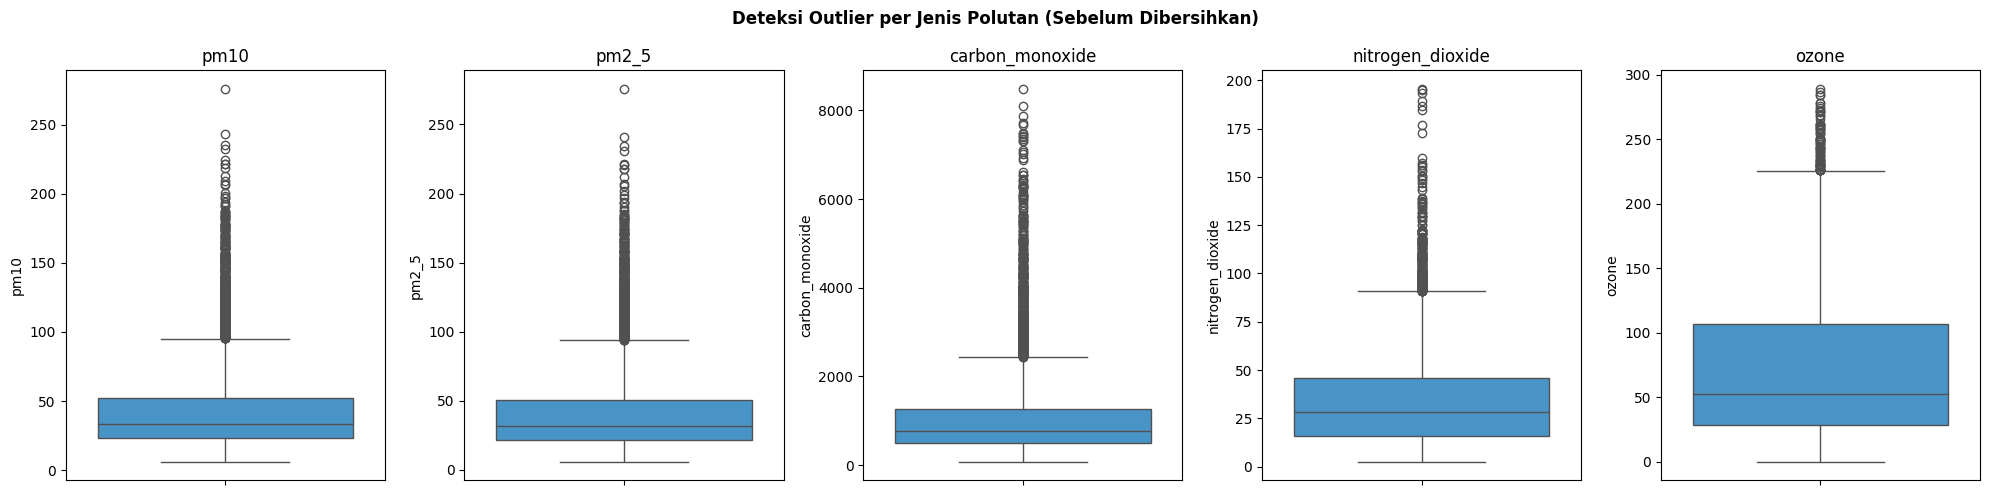

In [10]:
# Deteksi outlier ekstrem menggunakan visualisasi boxplot per kolom polutan (SEBELUM dibersihkan)
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(kolom_polutan):
    sns.boxplot(y=df[col], ax=axes[i], color='#3498db')
    axes[i].set_title(col)
plt.suptitle('Deteksi Outlier per Jenis Polutan (Sebelum Dibersihkan)', fontweight='bold')
plt.tight_layout()
plt.show()

# Mengubah nama kolom agar lebih ringkas

In [11]:
df.rename(columns={
    'carbon_monoxide': 'CO',
    'nitrogen_dioxide': 'NO2',
    'pm10': 'PM10',
    'pm2_5': 'PM2.5',
    'ozone': 'O3'
}, inplace=True)

# Membersihkan anomali: mengubah konsentrasi negatif menjadi Missing Values (NaN)

In [12]:
for col in ['PM10', 'PM2.5', 'CO', 'NO2', 'O3']:
    df.loc[df[col] < 0, col] = None

In [13]:
# Mengisi missing values (NaN) menggunakan interpolasi linear berbasis waktu
# Interpolasi dipilih karena data bersifat time-series dan nilai polutan
# cenderung berubah secara gradual antar-jam, bukan melompat drastis
#
# CATATAN PENTING: method='time' saja TIDAK bisa mengisi NaN yang berada di
# ujung awal atau ujung akhir deret waktu (leading/trailing NaN), karena tidak
# ada titik data di salah satu sisinya untuk diinterpolasi. Oleh karena itu
# ditambahkan limit_direction='both' agar NaN di kedua ujung juga tertangani
# (menggunakan nilai valid terdekat sebagai isian/extrapolasi sederhana).
df = df.set_index('time')
df[['PM10', 'PM2.5', 'CO', 'NO2', 'O3']] = df[['PM10', 'PM2.5', 'CO', 'NO2', 'O3']].interpolate(
    method='time', limit_direction='both'
)
df = df.reset_index()

# Verifikasi ulang tidak ada lagi missing values setelah interpolasi
print("Sisa missing values setelah interpolasi:")
print(df.isna().sum())

Sisa missing values setelah interpolasi:
time     0
PM10     0
PM2.5    0
CO       0
NO2      0
O3       0
dtype: int64


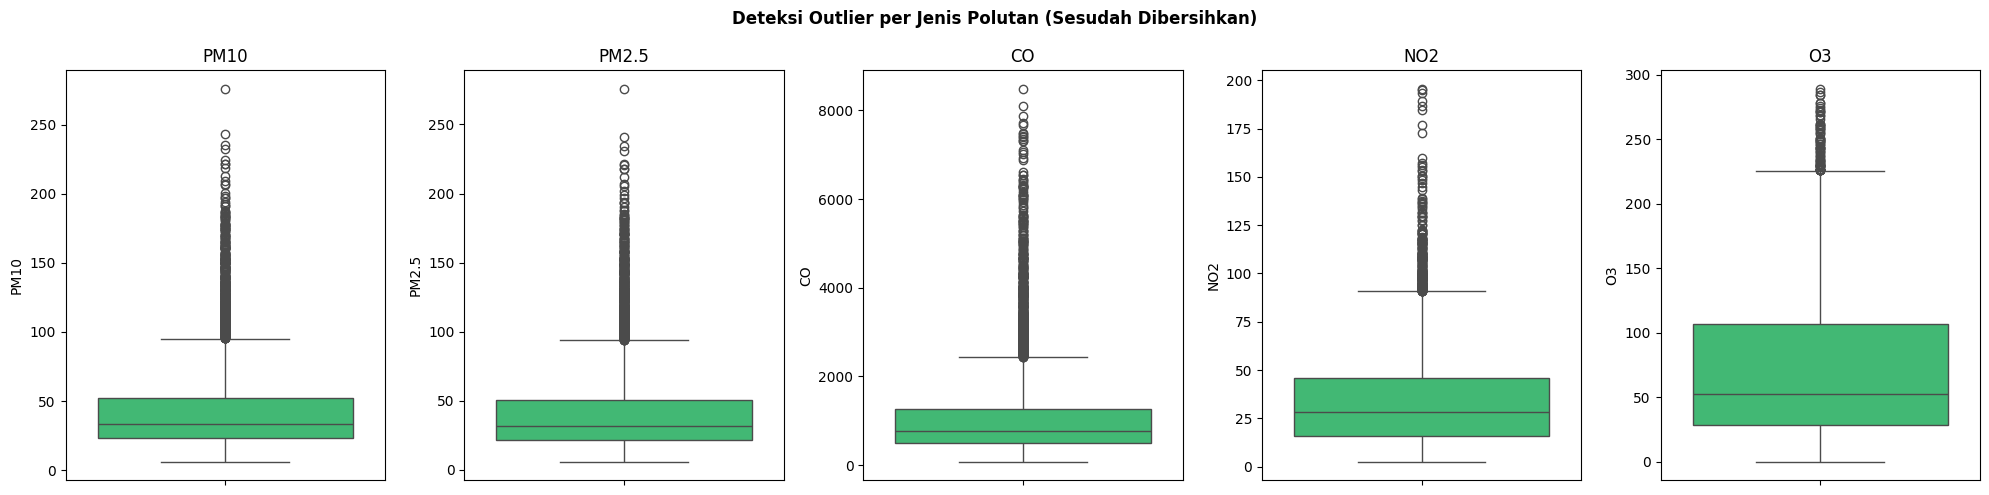

In [14]:
# Deteksi outlier SESUDAH dibersihkan, sebagai pembanding terhadap boxplot sebelumnya.
# Perbandingan ini penting untuk melihat apakah pembersihan nilai negatif juga
# berdampak pada sebaran/outlier data secara keseluruhan.
kolom_polutan_bersih = ['PM10', 'PM2.5', 'CO', 'NO2', 'O3']
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(kolom_polutan_bersih):
    sns.boxplot(y=df[col], ax=axes[i], color='#2ecc71')
    axes[i].set_title(col)
plt.suptitle('Deteksi Outlier per Jenis Polutan (Sesudah Dibersihkan)', fontweight='bold')
plt.tight_layout()
plt.show()

# Catatan interpretasi: outlier yang masih tersisa setelah pembersihan nilai
# negatif tidak serta-merta dihapus, karena bisa jadi merupakan kejadian nyata
# (misalnya lonjakan PM2.5 akibat kebakaran lahan/kemacetan ekstrem), bukan
# error pengukuran. Outlier semacam ini dibiarkan dalam data namun dicatat
# sebagai catatan analisis lanjutan.

# Mengurutkan waktu secara ASCENDING agar runtun waktu rapi (Data terlama di atas)

In [15]:
df = df.sort_values(by='time', ascending=True).reset_index(drop=True)

# Menyimpan Data menjadi CSV

In [16]:
csv_filename = "polutan_gresik_2025_2026.csv"
df.to_csv(csv_filename, index=False)
print(f"Data disimpan ke dalam bentuk file: {csv_filename}")

Data disimpan ke dalam bentuk file: polutan_gresik_2025_2026.csv


# Menampilkan cuplikan data teratas

In [17]:
df.head()

,time,PM10,PM2.5,CO,NO2,O3
0,2025-08-31 00:00:00,30.7,29.5,860.0,27.3,35.0
1,2025-08-31 01:00:00,39.1,37.6,911.0,29.3,30.0
2,2025-08-31 02:00:00,49.1,47.5,1077.0,31.7,24.0
3,2025-08-31 03:00:00,55.3,53.4,1303.0,34.4,17.0
4,2025-08-31 04:00:00,58.9,56.8,1507.0,36.9,16.0


---

## 4. Visualisasi Grafik (Time Series)
Langkah terakhir adalah memvisualisasikan data runtun waktu yang telah bersih untuk melihat pergerakan tren kualitas udaranya, sekaligus menjawab keempat pertanyaan pada Bagian 1.3: tren umum, pola harian, pola musiman, dan frekuensi pelanggaran ambang batas.

### A. Grafik Gas Emisi (CO dan NO2)
Kita me-resample datanya menjadi rata-rata harian agar grafik lebih mudah dibaca dan tidak terlalu menumpuk.

# Resample data per jam menjadi rata-rata harian (D = Daily)

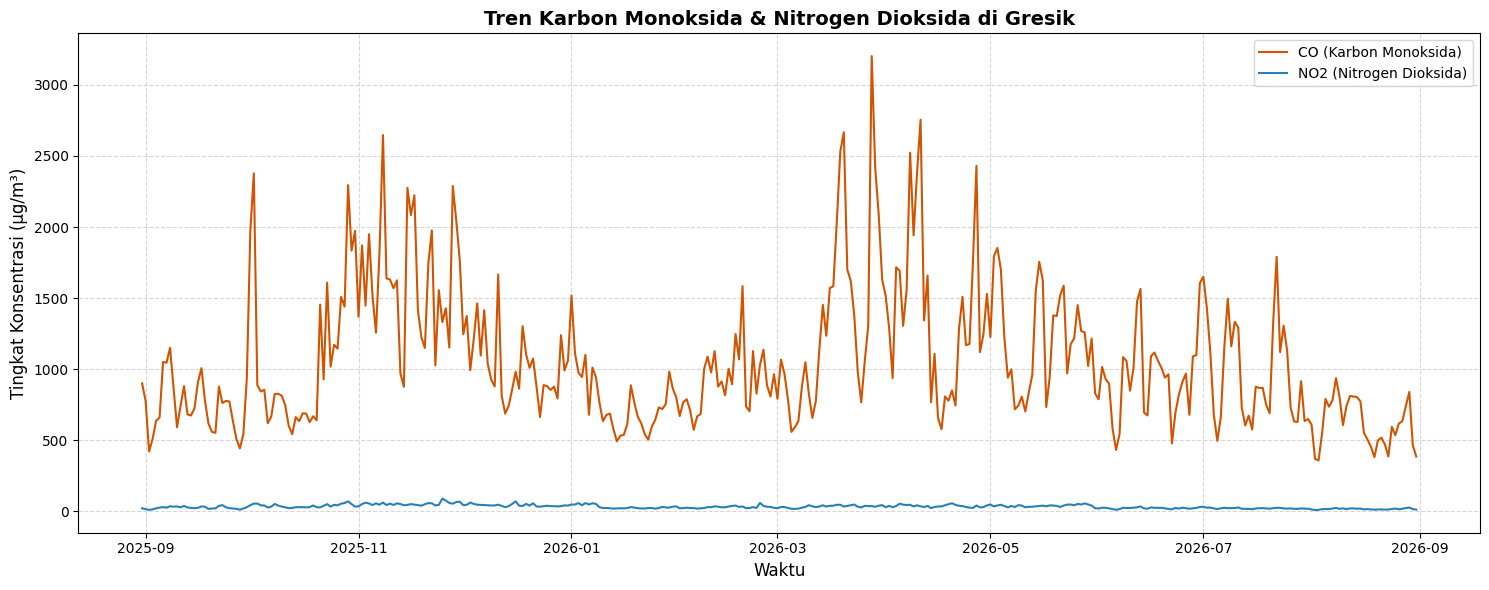

In [18]:
df_daily = df.resample('D', on='time').mean().reset_index()

# Konfigurasi kanvas Matplotlib
plt.figure(figsize=(15, 6))

# Plot Garis untuk Karbon Monoksida dan Nitrogen Dioksida
sns.lineplot(data=df_daily, x='time', y='CO', label='CO (Karbon Monoksida)', color='#d35400')
sns.lineplot(data=df_daily, x='time', y='NO2', label='NO2 (Nitrogen Dioksida)', color='#2980b9')

# Styling Grafik
plt.title('Tren Karbon Monoksida & Nitrogen Dioksida di Gresik', fontsize=14, fontweight='bold')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Tingkat Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### B. Grafik Partikel Berbahaya (PM10 dan PM2.5)
Partikulat sangat penting dipantau di wilayah pabrik dan kendaraan berat karena bentuk fisiknya berupa debu mikro yang berbahaya bagi pernapasan.

# Konfigurasi kanvas Matplotlib

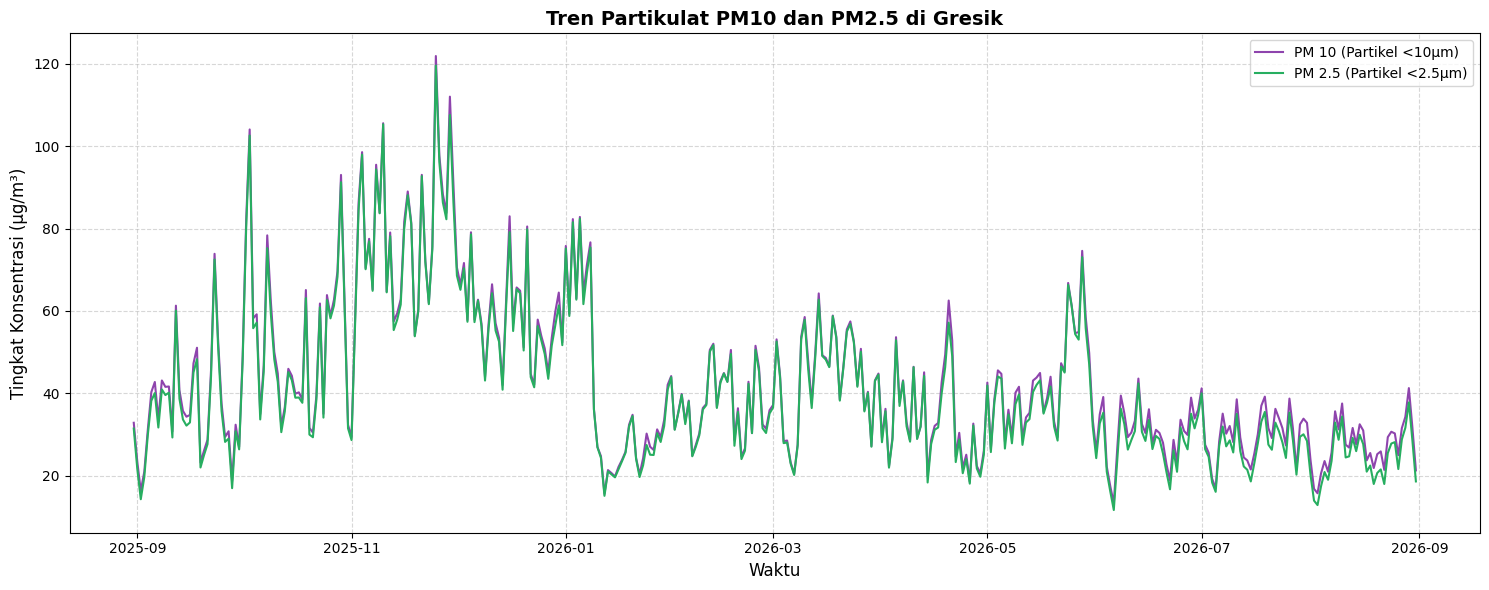

In [19]:
plt.figure(figsize=(15, 6))

# Plot Garis untuk Partikulat
sns.lineplot(data=df_daily, x='time', y='PM10', label='PM 10 (Partikel <10µm)', color='#8e44ad')
sns.lineplot(data=df_daily, x='time', y='PM2.5', label='PM 2.5 (Partikel <2.5µm)', color='#27ae60')

# Styling Grafik
plt.title('Tren Partikulat PM10 dan PM2.5 di Gresik', fontsize=14, fontweight='bold')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Tingkat Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### C. Grafik Ozon Permukaan (O3)
Karena O3 terbentuk dari reaksi fotokimia, polanya cenderung berbeda dengan polutan hasil emisi langsung (CO, NO2), sehingga divisualisasikan secara terpisah.

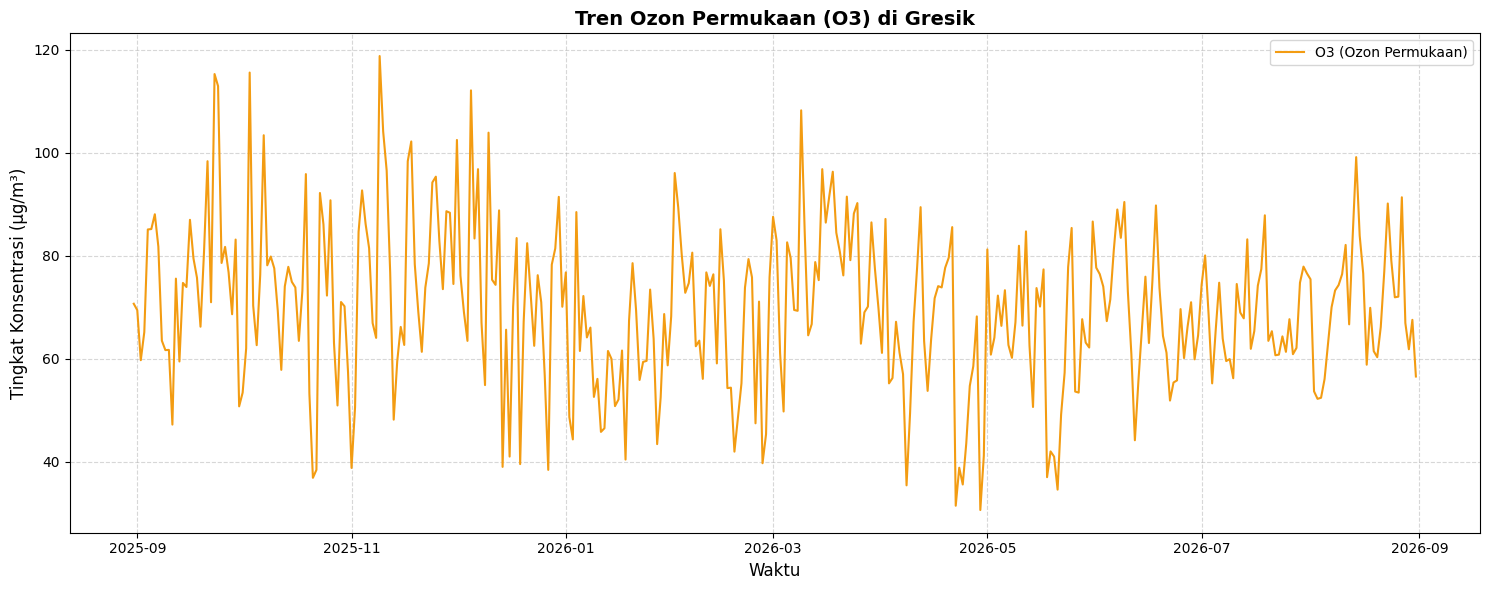

In [20]:
plt.figure(figsize=(15, 6))

sns.lineplot(data=df_daily, x='time', y='O3', label='O3 (Ozon Permukaan)', color='#f39c12')

plt.title('Tren Ozon Permukaan (O3) di Gresik', fontsize=14, fontweight='bold')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Tingkat Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

### D. Pola Harian (Jam Sibuk Lalu Lintas)

Grafik pada Bagian A–C menggunakan rata-rata harian sehingga pola dalam satu hari (24 jam) tidak terlihat. Bagian ini secara khusus menjawab pertanyaan riset "apakah polusi lebih tinggi di jam sibuk lalu lintas?" dengan mengelompokkan data berdasarkan jam (0–23) tanpa memandang tanggal.

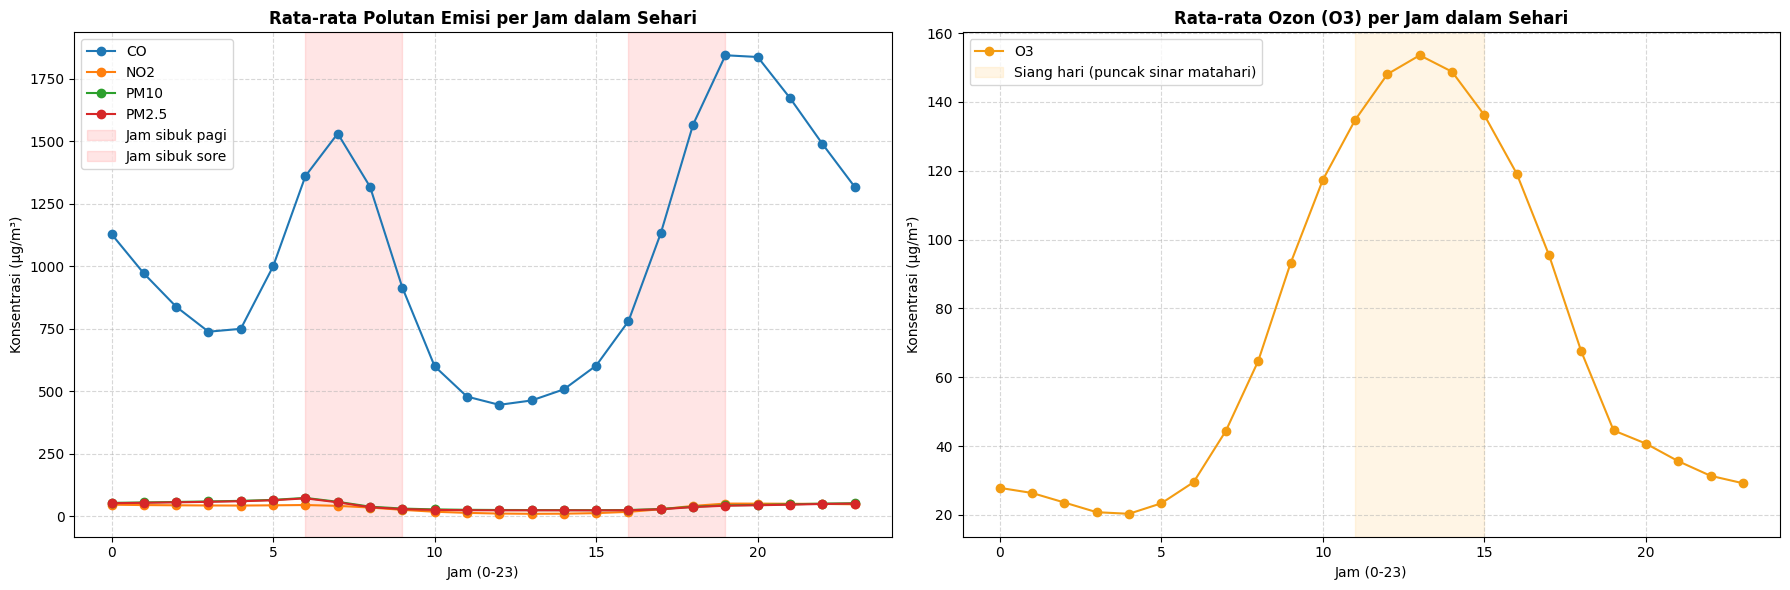

,CO,NO2,PM10,PM2.5,O3
hour,,,,,
0,1128.885246,45.735792,53.079781,51.592623,27.846995
1,971.428962,44.295902,54.787705,53.286612,26.360656
2,838.262295,43.348087,56.698361,55.187158,23.587432
3,738.270492,42.685246,58.803005,57.271858,20.775956
4,749.775956,42.302186,61.163115,59.615027,20.311475
5,999.655738,43.241530,65.029781,63.450273,23.352459
6,1361.084699,44.461749,72.967486,71.253279,29.497268
7,1531.601093,41.118852,57.305738,55.302186,44.431694
8,1318.463115,34.444809,37.898087,35.744262,64.707650


In [21]:
# Ekstrak jam dari kolom waktu (0-23)
df['hour'] = df['time'].dt.hour

# Rata-rata konsentrasi per jam sepanjang periode data
df_hourly_pattern = df.groupby('hour')[['CO', 'NO2', 'PM10', 'PM2.5', 'O3']].mean()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel kiri: polutan emisi langsung dari kendaraan (CO, NO2, PM10, PM2.5)
df_hourly_pattern[['CO', 'NO2', 'PM10', 'PM2.5']].plot(ax=axes[0], marker='o')
axes[0].set_title('Rata-rata Polutan Emisi per Jam dalam Sehari', fontweight='bold')
axes[0].set_xlabel('Jam (0-23)')
axes[0].set_ylabel('Konsentrasi (μg/m³)')
axes[0].axvspan(6, 9, color='red', alpha=0.1, label='Jam sibuk pagi')
axes[0].axvspan(16, 19, color='red', alpha=0.1, label='Jam sibuk sore')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Panel kanan: O3 dipisah karena polanya dibentuk oleh sinar matahari, bukan emisi langsung
df_hourly_pattern[['O3']].plot(ax=axes[1], marker='o', color='#f39c12')
axes[1].set_title('Rata-rata Ozon (O3) per Jam dalam Sehari', fontweight='bold')
axes[1].set_xlabel('Jam (0-23)')
axes[1].set_ylabel('Konsentrasi (μg/m³)')
axes[1].axvspan(11, 15, color='orange', alpha=0.1, label='Siang hari (puncak sinar matahari)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

df_hourly_pattern

Interpretasi yang diharapkan: polutan emisi langsung (CO, NO2, PM10, PM2.5) umumnya menunjukkan dua puncak yang berdekatan dengan jam sibuk lalu lintas (pagi dan sore), sedangkan O3 memuncak di siang hari karena terbentuk dari reaksi fotokimia yang membutuhkan intensitas sinar matahari tinggi.

### E. Pola Musiman (Kemarau vs Penghujan)

Untuk melihat pola musiman, data di-resample menjadi rata-rata bulanan, kemudian dikelompokkan ke musim kemarau (April–Oktober) dan musim hujan (November–Maret) sesuai pola iklim umum di Jawa Timur.

C:\Users\OKAN\AppData\Local\Temp\ipykernel_18192\2125794572.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample('M', on='time').mean(numeric_only=True).reset_index()


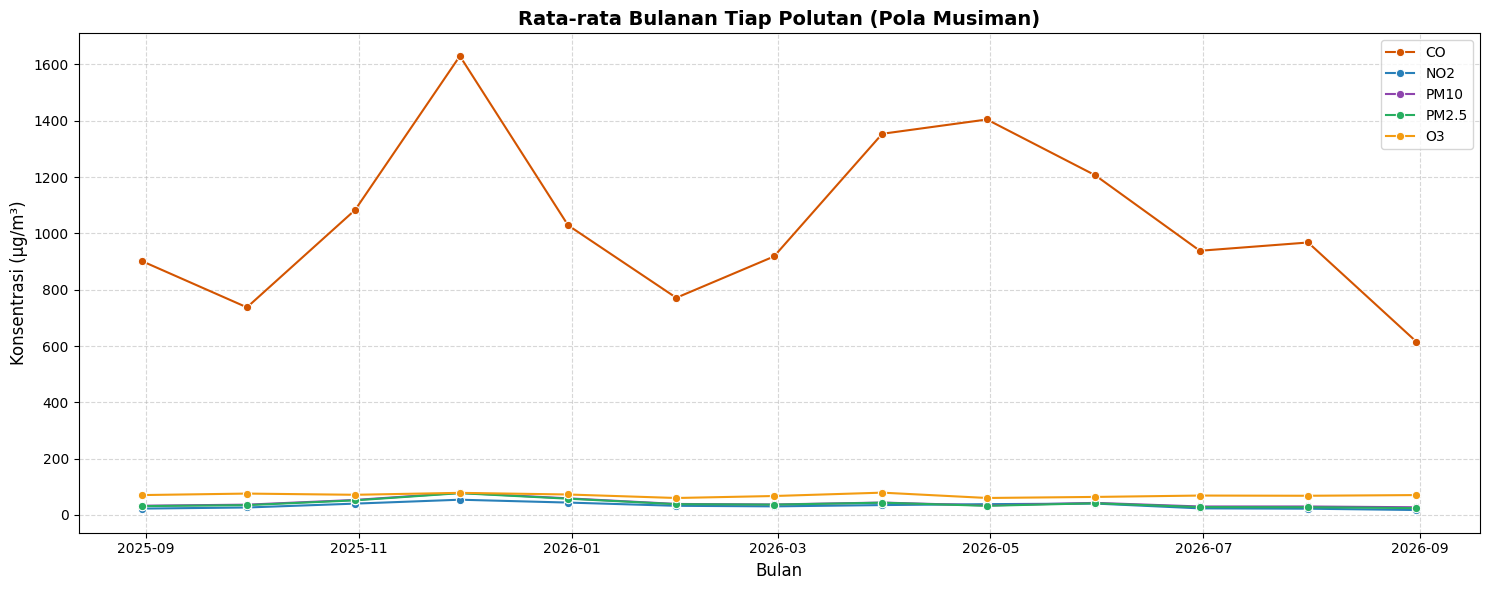

In [22]:
# Resample menjadi rata-rata bulanan untuk melihat tren musiman
df_monthly = df.resample('M', on='time').mean(numeric_only=True).reset_index()

plt.figure(figsize=(15, 6))
for col, color in zip(['CO', 'NO2', 'PM10', 'PM2.5', 'O3'],
                       ['#d35400', '#2980b9', '#8e44ad', '#27ae60', '#f39c12']):
    sns.lineplot(data=df_monthly, x='time', y=col, label=col, color=color, marker='o')

plt.title('Rata-rata Bulanan Tiap Polutan (Pola Musiman)', fontsize=14, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Konsentrasi (μg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [23]:
# Klasifikasi musim: Kemarau (Apr-Okt) vs Hujan (Nov-Mar), pola umum Jawa Timur
def klasifikasi_musim(bulan):
    return 'Kemarau' if bulan in [4, 5, 6, 7, 8, 9, 10] else 'Hujan'

df['musim'] = df['time'].dt.month.apply(klasifikasi_musim)

# Perbandingan rata-rata konsentrasi tiap polutan antar musim
perbandingan_musim = df.groupby('musim')[['CO', 'NO2', 'PM10', 'PM2.5', 'O3']].mean()
print("Rata-rata konsentrasi polutan per musim:")
perbandingan_musim

Rata-rata konsentrasi polutan per musim:


,CO,NO2,PM10,PM2.5,O3
musim,,,,,
Hujan,1141.550497,39.352345,51.721716,50.858720,71.666115
Kemarau,992.469244,29.843178,36.339419,34.404671,68.553101


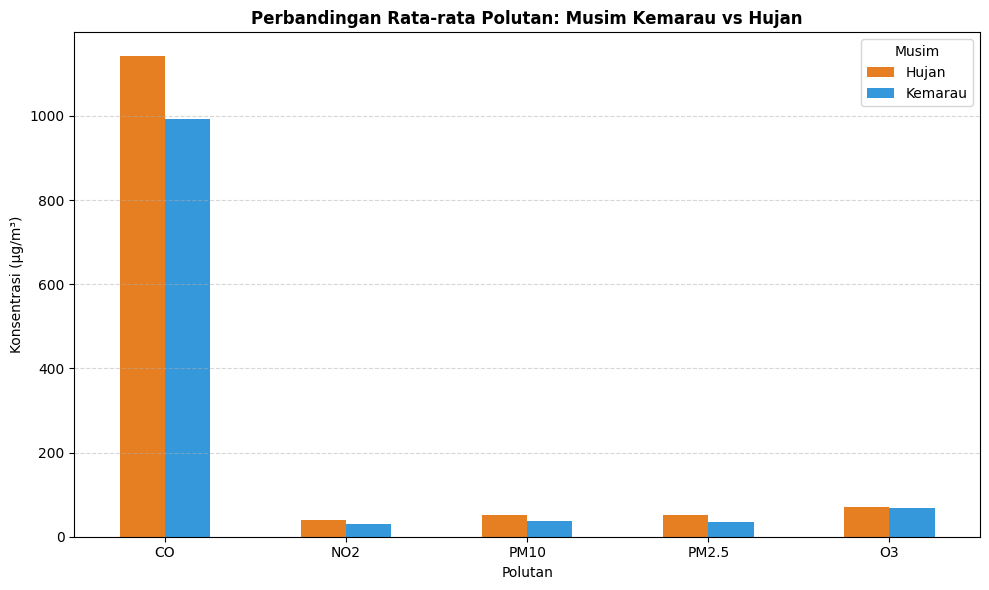

In [24]:
perbandingan_musim.T.plot(kind='bar', figsize=(10, 6), color=['#e67e22', '#3498db'])
plt.title('Perbandingan Rata-rata Polutan: Musim Kemarau vs Hujan', fontweight='bold')
plt.ylabel('Konsentrasi (μg/m³)')
plt.xlabel('Polutan')
plt.xticks(rotation=0)
plt.legend(title='Musim')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### F. Frekuensi Pelanggaran Ambang Batas Aman

Bagian ini menjawab pertanyaan riset terakhir: "polutan mana yang paling sering melebihi ambang batas aman?", menggunakan baku mutu udara ambien nasional (PP No. 22 Tahun 2021) yang sudah dijelaskan pada Bagian 2.3.

In [25]:
# Baku mutu udara ambien nasional (PP No. 22 Tahun 2021), dalam μg/m³
baku_mutu = {
    'CO': 10000,     # rata-rata 1 jam
    'NO2': 200,      # rata-rata 1 jam
    'PM10': 75,      # rata-rata 24 jam
    'PM2.5': 55,     # rata-rata 24 jam
    'O3': 150        # rata-rata 1 jam
}

hasil_pelanggaran = []
for polutan, batas in baku_mutu.items():
    jumlah_lewat = (df[polutan] > batas).sum()
    total_data = df[polutan].notna().sum()
    persen_lewat = (jumlah_lewat / total_data) * 100
    hasil_pelanggaran.append({
        'Polutan': polutan,
        'Baku Mutu (μg/m³)': batas,
        'Jumlah Jam Melebihi': jumlah_lewat,
        'Persentase Waktu Melebihi (%)': round(persen_lewat, 2)
    })

df_pelanggaran = pd.DataFrame(hasil_pelanggaran).sort_values(
    by='Persentase Waktu Melebihi (%)', ascending=False
).reset_index(drop=True)

print("Ringkasan frekuensi pelanggaran ambang batas per polutan:")
df_pelanggaran

Ringkasan frekuensi pelanggaran ambang batas per polutan:


,Polutan,Baku Mutu (μg/m³),Jumlah Jam Melebihi,Persentase Waktu Melebihi (%)
0,PM2.5,55,1874,21.33
1,PM10,75,1052,11.98
2,O3,150,903,10.28
3,CO,10000,0,0.00
4,NO2,200,0,0.00


C:\Users\OKAN\AppData\Local\Temp\ipykernel_18192\859491421.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pelanggaran, x='Polutan', y='Persentase Waktu Melebihi (%)', palette='Reds_r')


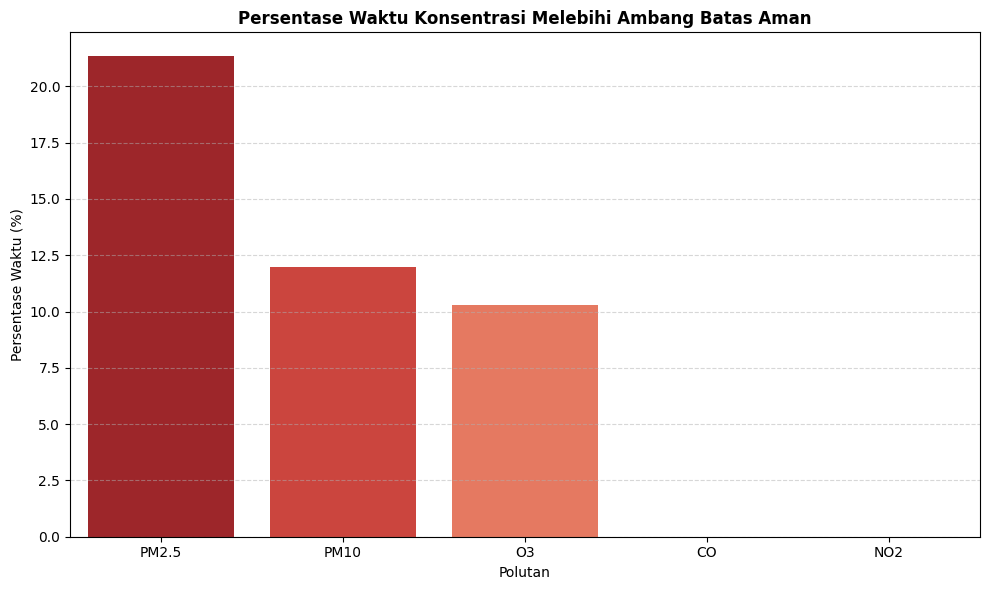

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_pelanggaran, x='Polutan', y='Persentase Waktu Melebihi (%)', palette='Reds_r')
plt.title('Persentase Waktu Konsentrasi Melebihi Ambang Batas Aman', fontweight='bold')
plt.ylabel('Persentase Waktu (%)')
plt.xlabel('Polutan')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

```{note}
Perlu diperhatikan bahwa baku mutu PM10, PM2.5 (rata-rata 24 jam) dan CO, NO2, O3 (rata-rata 1 jam) memiliki basis waktu rata-rata yang berbeda. Perhitungan di atas menerapkan ambang batas langsung pada data per jam sebagai pendekatan sederhana (screening); untuk kesimpulan yang lebih presisi terhadap PM10/PM2.5, idealnya dihitung dari rata-rata bergerak 24 jam (`df[col].rolling('24H').mean()`) sebelum dibandingkan dengan baku mutunya.
```

### G. Ringkasan Statistik Akhir

In [27]:
# Ringkasan statistik harian dari seluruh polutan setelah proses pembersihan
df_daily[['CO', 'NO2', 'PM10', 'PM2.5', 'O3']].describe()

,CO,NO2,PM10,PM2.5,O3
count,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1053.975444,33.766359,42.685667,41.193090,69.837432
std,477.475355,13.190807,19.016537,19.141630,15.489676
min,358.791667,10.295833,13.295833,11.700000,30.625000
25%,705.864583,23.357292,29.307292,27.692708,60.791667
50%,928.479167,31.531250,36.850000,35.525000,69.854167
75%,1277.750000,42.361458,53.157292,52.200000,78.708333
max,3202.875000,90.745833,121.845833,119.529167,118.750000


---

## 5. Kesimpulan

Berdasarkan eksplorasi dan visualisasi di atas, beberapa hal yang dapat disimpulkan (silakan sesuaikan dengan hasil aktual dari data yang ditarik setelah kode dijalankan):
*   **Tren umum:** Tren konsentrasi masing-masing polutan selama satu tahun terakhir dapat diamati melalui grafik time series harian di Bagian 4.A–4.C.
*   **Pola harian:** Bagian 4.D menunjukkan apakah polutan emisi kendaraan (CO, NO2, PM10, PM2.5) memuncak di jam sibuk lalu lintas (pagi/sore), sementara O3 diperkirakan memuncak siang hari akibat proses fotokimia.
*   **Pola musiman:** Bagian 4.E membandingkan rata-rata bulanan dan rata-rata musim kemarau vs hujan; secara umum diharapkan konsentrasi partikulat (PM10/PM2.5) lebih tinggi di musim kemarau karena kondisi udara lebih kering dan minim hujan yang biasanya "mencuci" partikel di udara.
*   **Anomali data:** Proses pembersihan data (penanganan nilai negatif dan missing values melalui interpolasi dua arah) memastikan data yang dianalisis lebih valid secara logis; boxplot sebelum/sesudah pembersihan di Bagian 3.C digunakan untuk memverifikasi hal ini.
*   **Pelanggaran ambang batas:** Bagian 4.F menjawab polutan mana yang paling sering melewati baku mutu nasional, sebagai indikator prioritas polutan yang perlu diwaspadai di wilayah kajian.
*   Hasil analisis ini dapat menjadi acuan awal bagi masyarakat dan pemerintah setempat dalam memahami pola kualitas udara di Gresik, serta menjadi dasar untuk kajian lanjutan seperti pemodelan prediksi (forecasting) polutan.